Import


In [1]:
# ==========================================
# STEP 0 — Imports
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Set plotting defaults
plt.style.use("ggplot")

Load Data

In [2]:
# Replace with your file paths
wearable_path = "C:\\Users\\Nicholas Santoso\\Downloads\\recordings (week of 29th) (1)\\position - ellie 29-01-26\\LATERAL\\recording_20260129_113120.csv"
control_path = "C:\\Users\\Nicholas Santoso\\Downloads\\recordings (week of 29th) (1)\\position - ellie 29-01-26\\LATERAL\\recording_20260129_113120.csv"

wearable = pd.read_csv(wearable_path)
control = pd.read_csv(control_path)

# Extract channel columns (Channel_1 .. Channel_64)
channel_cols = [f"Channel_{ch}" for ch in range(1, 65)]

print("Wearable shape:", wearable.shape)
print("Control shape:", control.shape)

Wearable shape: (111250, 73)
Control shape: (111250, 73)


DSP Parameters & Per-Channel Processing

In [3]:
# DSP Parameters (matching rhett.rmd)
fs = 1000        # Sampling rate (Hz)
lowcut = 10      # Low-pass cutoff for envelope (Hz)
b, a = butter(4, lowcut / (fs / 2), btype='low')

def calc_channel_stats(x, b, a):
    """Process a single channel: dead check, envelope segmentation, RMS & SNR."""
    x = x.values if hasattr(x, 'values') else np.asarray(x)
    x = x[~np.isnan(x)]

    # Dead channel check
    if np.std(x) < 0.001:
        return dict(rest_rms=np.nan, active_rms=np.nan, snr=np.nan, is_dead=1)

    # Envelope detection
    rectified = np.abs(x - np.mean(x))
    envelope = filtfilt(b, a, rectified)
    threshold = np.mean(envelope) + 2 * np.std(envelope)

    active_idx = envelope >= threshold

    # RMS helper
    def calc_rms(v):
        if len(v) == 0:
            return np.nan
        return np.sqrt(np.mean(v ** 2))

    rest_rms = calc_rms(x[~active_idx])
    active_rms = calc_rms(x[active_idx])

    # SNR
    if not np.isnan(rest_rms) and rest_rms > 0:
        snr = 20 * np.log10(active_rms / rest_rms)
    else:
        snr = np.nan

    return dict(rest_rms=rest_rms, active_rms=active_rms, snr=snr, is_dead=0)

# Process all 64 channels for both wearable and control
results = []
for ch in range(1, 65):
    col = f"Channel_{ch}"
    w_stats = calc_channel_stats(wearable[col], b, a)
    c_stats = calc_channel_stats(control[col], b, a)
    results.append({
        "channel": ch,
        "w_rest_rms": w_stats["rest_rms"],
        "w_active_rms": w_stats["active_rms"],
        "w_snr": w_stats["snr"],
        "w_dead": w_stats["is_dead"],
        "c_rest_rms": c_stats["rest_rms"],
        "c_active_rms": c_stats["active_rms"],
        "c_snr": c_stats["snr"],
        "c_dead": c_stats["is_dead"],
    })

stats_df = pd.DataFrame(results)
stats_df.head(10)

,channel,w_rest_rms,w_active_rms,w_snr,w_dead,c_rest_rms,c_active_rms,c_snr,c_dead
0,1,387.147337,1211.736215,9.910636,0,387.147337,1211.736215,9.910636,0
1,2,419.925131,1307.929227,9.868248,0,419.925131,1307.929227,9.868248,0
2,3,435.853507,1368.414586,9.937543,0,435.853507,1368.414586,9.937543,0
3,4,444.947855,1407.474142,10.002626,0,444.947855,1407.474142,10.002626,0
4,5,441.300299,1398.860242,10.020802,0,441.300299,1398.860242,10.020802,0
5,6,427.253419,1378.141006,10.172162,0,427.253419,1378.141006,10.172162,0
6,7,414.783995,1353.263106,10.271205,0,414.783995,1353.263106,10.271205,0
7,8,401.632443,1301.284815,10.210872,0,401.632443,1301.284815,10.210872,0
8,9,426.881615,1296.300005,9.647961,0,426.881615,1296.300005,9.647961,0
9,10,471.347760,1465.644028,9.853741,0,471.347760,1465.644028,9.853741,0


Active RMS Heatmaps (8x8 Grid)

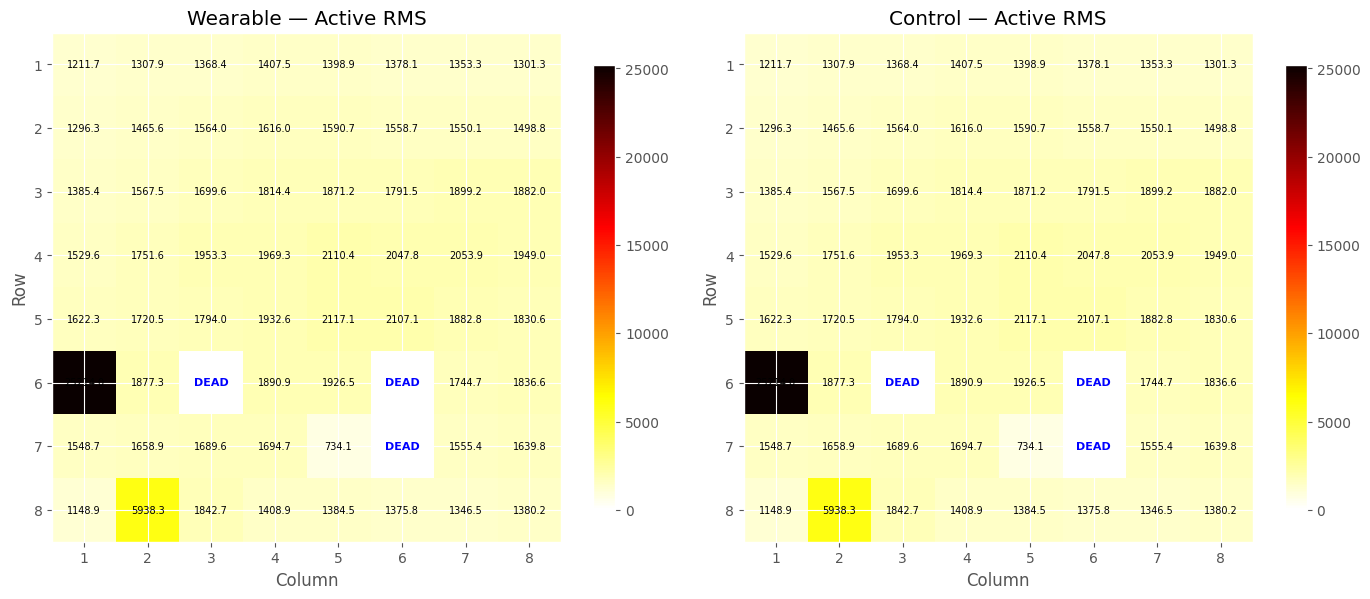

In [4]:
def plot_rms_heatmap(ax, active_rms_vals, is_dead_vals, title):
    """Plot an 8x8 active RMS heatmap with dead channel labels."""
    # Replace NaN (dead channels) with 0 for color mapping
    plot_vals = active_rms_vals.copy()
    plot_vals[np.isnan(plot_vals)] = 0

    rms_grid = plot_vals.reshape(8, 8)
    dead_grid = is_dead_vals.reshape(8, 8)

    im = ax.imshow(rms_grid, cmap="hot_r", aspect="equal")

    # Annotate each cell
    for row in range(8):
        for col in range(8):
            if dead_grid[row, col] == 1:
                ax.text(col, row, "DEAD", ha="center", va="center",
                        fontsize=8, color="blue", fontweight="bold")
            else:
                ax.text(col, row, f"{rms_grid[row, col]:.1f}",
                        ha="center", va="center", fontsize=7, color="black")

    ax.set_title(title)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))
    ax.set_xticklabels(range(1, 9))
    ax.set_yticklabels(range(1, 9))
    return im

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = plot_rms_heatmap(axes[0],
                       stats_df["w_active_rms"].values,
                       stats_df["w_dead"].values,
                       "Wearable — Active RMS")

im2 = plot_rms_heatmap(axes[1],
                       stats_df["c_active_rms"].values,
                       stats_df["c_dead"].values,
                       "Control — Active RMS")

plt.colorbar(im1, ax=axes[0], shrink=0.8)
plt.colorbar(im2, ax=axes[1], shrink=0.8)
plt.tight_layout()
plt.show()

Summary

In [5]:
# Summary statistics (matching rhett.rmd output)
w_valid = stats_df[stats_df["w_dead"] == 0]
c_valid = stats_df[stats_df["c_dead"] == 0]

w_snr_finite = w_valid["w_snr"][np.isfinite(w_valid["w_snr"])]
c_snr_finite = c_valid["c_snr"][np.isfinite(c_valid["c_snr"])]

summary = pd.DataFrame({
    "Metric": ["Dead Channels", "Avg Active RMS", "Avg Rest RMS", "Avg SNR (dB)"],
    "Wearable": [
        int(stats_df["w_dead"].sum()),
        w_valid["w_active_rms"].mean(),
        w_valid["w_rest_rms"].mean(),
        w_snr_finite.mean() if len(w_snr_finite) > 0 else np.nan,
    ],
    "Control": [
        int(stats_df["c_dead"].sum()),
        c_valid["c_active_rms"].mean(),
        c_valid["c_rest_rms"].mean(),
        c_snr_finite.mean() if len(c_snr_finite) > 0 else np.nan,
    ],
})

print(summary.to_string(index=False))

        Metric    Wearable     Control
 Dead Channels    3.000000    3.000000
Avg Active RMS 2098.152081 2098.152081
  Avg Rest RMS  564.775240  564.775240
  Avg SNR (dB)   10.834999   10.834999
